# Data Cleaning, CCA, Skew-Based Imputation and Distance Matrix Computation

This notebook performs comprehensive data cleaning. Missing values are handled via Complete Case Analysis (CCA) for columns with <= 5% missing data. For columns with > 5% missing data, we use mean imputation if the data is normally distributed (skewness between -0.5 and 0.5) and median imputation if skewed. PDF plots are generated before and after imputation.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_excel("data/lab2_data.xlsx")
print("Original Shape:", df.shape)

Original Shape: (163, 14)


In [2]:
def clean_salary(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).lower().strip()
    
    # Handle non-numeric conversational responses
    if any(word in val_str for word in ['high', 'nothing', 'expect', 'security']):
        return np.nan
        
    # Handle 'cr' (Crore -> 100 Lakhs)
    if 'cr' in val_str:
        num = re.findall(r"[-+]?\d*\.\d+|\d+", val_str)
        if num:
            return float(num[0]) * 100
            
    # Extract numbers
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", val_str)
    if not nums:
        return np.nan
        
    num = float(nums[0])
    
    # If the number is large (e.g., >= 10000), it's probably actual salary instead of LPA
    if num >= 10000:
        num = num / 100000
        
    return num

def clean_percentage(val):
    if pd.isna(val) or val == '-':
        return np.nan
    try:
        num = float(val)
        if num <= 1.0: # It's a decimal percentage (e.g., 0.75 -> 75)
            return num * 100
        return num
    except (ValueError, TypeError):
        return np.nan

In [3]:
# Define column groups
salary_cols = [
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)',
    'What are your package expectations (LPA)'
]

percentage_cols = [
    'your CIA % of last semester',
    'your GPA of last semester',
    'Your maximum attendance % till last semester'
]

# Apply custom cleaning functions
for col in salary_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_salary)

for col in percentage_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_percentage)

# Convert remaining numeric columns properly (like 'Rate your technical competencies')
other_numeric_cols = ['Rate your contribution towards extra curricular activities', 'Rate your technical competencies']
for col in other_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter to numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

In [4]:
# Calculate missing percentages
missing_pct = numeric_df.isna().mean() * 100
print("Missing Data Percentages: ", missing_pct[missing_pct > 0].sort_values(ascending=False))

# Complete Case Analysis (CCA): Drop rows with missing values where missing % <= 5%
cca_cols = missing_pct[(missing_pct > 0) & (missing_pct <= 5.0)].index.tolist()

if cca_cols:
    print(f"Applying CCA (dropping rows) for columns with <= 5% missing data: {cca_cols}")
    numeric_df = numeric_df.dropna(subset=cca_cols)
    print("Shape after CCA:", numeric_df.shape)
else:
    print("No columns meet the <= 5% missing data criteria for CCA.")

Missing Data Percentages:  your CIA % of last semester                                                                   7.975460
your GPA of last semester                                                                     6.748466
What is the  median salary of students placed through campus (In LPA..respond as a number)    3.680982
Your maximum attendance % till last semester                                                  3.680982
What is the maximum salary of students placed through campus (In LPA..respond as a number)    3.067485
What are your package expectations (LPA)                                                      3.067485
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0.613497
Rate your contribution towards extra curricular activities                                    0.613497
dtype: float64
Applying CCA (dropping rows) for columns with <= 5% missing data: ['What is the minimum salary of students placed through campus (In L

In [5]:
# Identify columns requiring imputation (> 5% missing)
impute_cols = missing_pct[missing_pct > 5.0].index.tolist()
print("Columns requiring imputation (> 5% missing):", impute_cols)

# Keep a copy of data before imputation for PDF plots
pre_imputation_df = numeric_df.copy()

Columns requiring imputation (> 5% missing): ['your CIA % of last semester', 'your GPA of last semester']


In [6]:
# We will store the chosen imputation method to inform our plotting titles
imputation_methods = {}

for col in impute_cols:
    # Calculate skewness of the non-missing data in the column
    skewness = numeric_df[col].dropna().skew()
    
    # Normally distributed check (skewness between -0.5 and 0.5)
    if abs(skewness) <= 0.5:
        print(f"{col}: Skewness = {skewness:.2f} -> Normal distribution -> MEAN imputation")
        numeric_df[col] = numeric_df[col].fillna(numeric_df[col].mean())
        imputation_methods[col] = 'Mean'
    else:
        print(f"{col}: Skewness = {skewness:.2f} -> Skewed distribution -> MEDIAN imputation")
        numeric_df[col] = numeric_df[col].fillna(numeric_df[col].median())
        imputation_methods[col] = 'Median'


your CIA % of last semester: Skewness = -2.13 -> Skewed distribution -> MEDIAN imputation
your GPA of last semester: Skewness = -0.58 -> Skewed distribution -> MEDIAN imputation


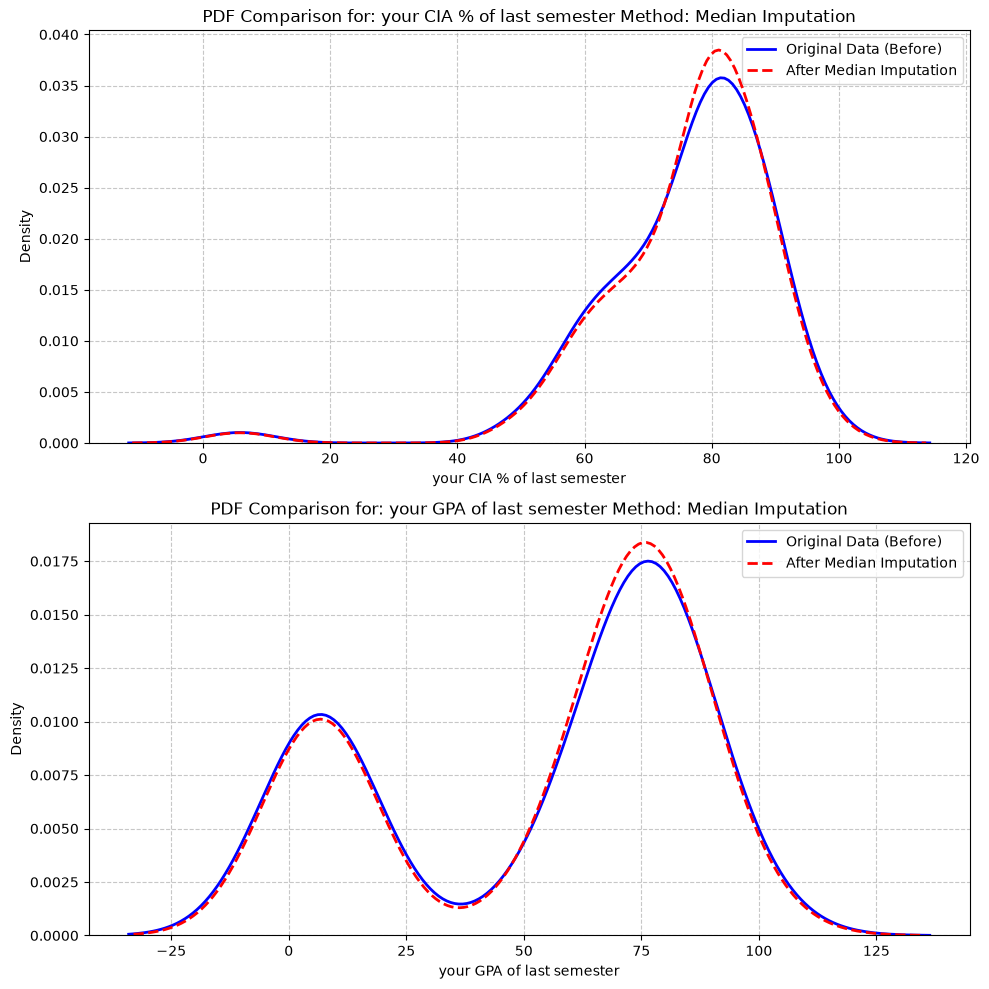

In [7]:
# Plot PDFs for columns that were imputed
if impute_cols:
    fig, axes = plt.subplots(len(impute_cols), 1, figsize=(10, 5 * len(impute_cols)))
    
    # Handle case where there's only 1 column to impute
    if len(impute_cols) == 1:
        axes = [axes]
        
    for i, col in enumerate(impute_cols):
        ax = axes[i]
        
        # Plot Original (Before Imputation)
        sns.kdeplot(pre_imputation_df[col].dropna(), ax=ax, label='Original Data (Before)', color='blue', linewidth=2)
        
        # Plot Imputed (After Imputation)
        sns.kdeplot(numeric_df[col], ax=ax, label=f'After {imputation_methods[col]} Imputation', color='red', linestyle='--', linewidth=2)
        
        ax.set_title(f'PDF Comparison for: {col} Method: {imputation_methods[col]} Imputation', fontsize=12)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.show()
else:
    print("No columns required imputation (all missing data was handled by CCA or no missing data existed).")

In [8]:
# Standardize the fully cleaned data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns, index=numeric_df.index)
print("Shape of standardized numeric data:", scaled_df.shape)

# Distance Computations
# 1. Euclidean Distance
euclidean_dist = pairwise_distances(scaled_df, metric='euclidean')
print("Euclidean Distance Matrix: ", euclidean_dist)

# 2. Manhattan Distance
manhattan_dist = pairwise_distances(scaled_df, metric='manhattan')
print("Manhattan Distance Matrix: ", manhattan_dist)

# 3. Minkowski Distance
minkowski_dist = pairwise_distances(scaled_df, metric='minkowski', p=3)
print("Minkowski Distance Matrix (p=3): ", minkowski_dist)

Shape of standardized numeric data: (147, 9)
Euclidean Distance Matrix:  [[0.         3.37935388 2.87452591 ... 3.77508259 3.85345622 3.02211379]
 [3.37935388 0.         1.71120481 ... 2.80646537 2.33043235 2.84131541]
 [2.87452591 1.71120481 0.         ... 2.63565682 2.77947696 2.54942989]
 ...
 [3.77508259 2.80646537 2.63565682 ... 0.         1.60161495 1.32961006]
 [3.85345622 2.33043235 2.77947696 ... 1.60161495 0.         1.90135499]
 [3.02211379 2.84131541 2.54942989 ... 1.32961006 1.90135499 0.        ]]
Manhattan Distance Matrix:  [[0.         5.60189565 4.84236292 ... 8.57333145 6.8594907  6.4312548 ]
 [5.60189565 0.         3.22101264 ... 5.03505324 2.56022045 4.87775397]
 [4.84236292 3.22101264 0.         ... 4.65852848 5.33406316 4.38590168]
 ...
 [8.57333145 5.03505324 4.65852848 ... 0.         2.80612449 2.29557787]
 [6.8594907  2.56022045 5.33406316 ... 2.80612449 0.         2.98021595]
 [6.4312548  4.87775397 4.38590168 ... 2.29557787 2.98021595 0.        ]]
Minkowski D